In [1]:
%matplotlib inline

In [2]:
# Import your libraries here

import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import requests
import time
from tqdm import tqdm
import torch
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

import statsmodels.api as sm
from scipy import stats
import seaborn as sns

In [3]:
notebook_path = Path(os.getcwd()).resolve()

PROJECT_ROOT = notebook_path.parent
DATA_DIR = PROJECT_ROOT / "static_data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook Path: {notebook_path}")
print(f"Project Root:  {PROJECT_ROOT}")
print(f"Data Dir:      {DATA_DIR}")

Notebook Path: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\notebooks
Project Root:  D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project
Data Dir:      D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\static_data


In [4]:
# Import your modules here
import importlib

import src.plotting_utils.plotting_utils as plot_utils
from src.data_pipeline_utils import data_fetching_handling as data_pipe
from src.data_pipeline_utils import edgar_scraping_utils as edgar_scrape
import src.nlp_utils.nlp_utils as nlp_utils
import src.signal_testing_utils.signal_testing_utils as sig_utils

#Establish the URL link to Google Cloud Storage
BASE_URL = "https://storage.googleapis.com/softuni_data_science_final_project_kamend1/static_data/"

importlib.reload(plot_utils)
importlib.reload(data_pipe)
importlib.reload(nlp_utils)
importlib.reload(sig_utils)

<module 'src.signal_testing_utils.signal_testing_utils' from 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Data_Science\\08_final_project\\src\\signal_testing_utils\\signal_testing_utils.py'>

### Introduction and goal of this notebook

In this notebook, I will establish the process of researching and obtaining the second dataset for this porject. 

It will consist ot text samples of the earnings press releases from earnings announcement 8-K type reports and the management discussion and analysis (MD&A) sections of quarterly earnings 10-Q type reports. 

**N.B.!** After I experienced the initial project setback by realizing it is not feasible to obtain actual earnings calls transcripts without breaching ethical and legal boundaries of data aggregators, I believe this is going to be the second-best option to fall back on. 

I will make a more detailed discussion on the possible presence of **Management Bias** in the text samples selected via this method and the possibility of it contaminating the scientific study and leading to inconclusive results from a statistical standpoint.

**Parts of this notebook are optional** as I will directly provide the final dataset after all data handling and extraction operations. You can observe, test the sample tests, or uncomment the alternate route in cells and fully commented-out cells to directly run the notebook to reproduce the results, or pull a fresh window of results as time moves on, and the data will become stale in the future.

The process includes:
- Obtain a history of filings for the group of selected companies
- Convert filing date to Pandas datetime
- Filter the required sample - in my case, I will focus on filings after 2016-03-31, which currently is the last 10 years
- Use the Data column in the Data Frame to filter the 8-K reports, which contain earnings
- Scrape the EDGAR database to confirm that the ITEMS field on this record contains Item 2.02, which is the only indicator we have that an 8-K report is needed
- Scrape the EDGAR database to obtain Exhibit 99.1 press releases from the filtered 8-K reports and the MD&A sections from the 10-Q reports
- Verify I now have a full working dataset
- Clean the text of unnecessary strings with no information value
- Utilize the services of the free tier of Google Cloud Storage, as the dataset will likely be hundreds of megabytes.

After the raw dataset is prepared, I will use the services of a pretrained model for natural language processing for finance to obtain a sentiment score of the extracted and cleaned texts. Finally, I will combine the chronological data of sentiment scores and stock returns. I will test whether the sentiment scores can provide any statistically significant predictive relationship with prices on the same day T+0, next day T+1, T + 2 days, T + 3 days, and T + 5 days. Finally, I will make a discussion of the results and provide the conclusions.

I would like to emphasize again that this notebook is only a proof of concept and a source of data obtaining, and it remains optional to implement, as the next notebook will utilize the final product via prepared static files on Google Cloud Storage.

**Source of preliminary information** - [Calcbench filing filter](https://www.calcbench.com/filings?pg_classificationMethod=tickers&pg_tickers=AMD,GOOG,AAPL,T,BAC,CAT,CVX,CB,DE,XOM,FE,F,INTC,JNJ,JPM,LMT,MCD,MSFT,NKE,NVDA,ORCL,PFE,PG,CRM,TGT,UPS,VZ,V,WMT,DIS&pc_rangeOption=All%20History&f_filingTypes=BusinessWirePR_filedAfterAn8K&f_filingTypes=BusinessWirePR_replaced&f_filingTypes=proxy&f_filingTypes=annualQuarterlyReport&f_filingTypes=eightk_earningsPressRelease&f_filingTypes=eightk_guidanceUpdate&f_filingTypes=eightk_presentationSlides&f_filingTypes=eightk_monthlyOperatingMetrics&f_filingTypes=eightk_earningsPressRelease_preliminary&f_filingTypes=eightk_earningsPressRelease_correction&f_filingTypes=eightk_other&f_filingTypes=commentLetter&f_filingTypes=commentLetterResponse&f_filingTypes=eightk_nonfinancial&f_filingTypes=NT10KorQ&f_filingTypes=S&f_filingTypes=Four24B&f_filingTypes=institutionalOwnsership_13F&f_filingTypes=ForeignAnnualOrInterimReport) - Exported from Calcbench on 2026-03-31. 

I have access to Calcbench through my CFA Institute member benefits. However, this particular Calbench service appears to be generally part of the free tier service provided by this organization, and the link provided above opens without authentication. It can be used to obtain fresh data and perform the data extraction as explained in this notebook. The end goal is to actually have a list of tickers and to extract all the history of filings these public companies committed to the SEC under legal requirements. EDGAR also allows for complex scraping to obtain such data.  

For the purpose of all data exercises regarding the central thesis of this project, I will use a **fixed dataset**, which will be available in Google Cloud Storage, where I will use a bucket with free access to view by all users. This notebook serves to explain the roadmap I went through in order to prepare the data, which I intend to use further down the road. 

What Calcbench did was provide the date of the filing and the link as a URL saved in a string format to the SEC's EDGAR database. This simply saves several hours of manual work in EDGAR itself or complex scraping algorithms. The same sample could be obtained using varying techniques with the [edgartools Python library](https://edgartools.readthedocs.io/en/latest), which is new to me, and I will invest time in the future to learn how to handle data extraction.

Below, the historical extract will be directly read from the static data located in Google Storage, and afterwards, I will perform and explain the logic behind several data handling operations. 

#### 1. So, let's extract the static data in a Data Frame

In [5]:
# As a reminder, I will declare the tickers variable as in the starting workbook 1_1
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

# Extract the data from the calcbench CSV file
filing_data = pd.read_csv(BASE_URL + "calcbench_filings.csv", sep=';')

# Alternatively, you can save your new CSV file locally to static_data and afterwards read from there
# filing_data = pd.read_csv("DATA_DIR / calcbench_filings.csv", sep=';')

filing_data

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data
0,2575776,ADVANCED MICRO DEVICES INC,AMD,2488,26.3.2026,DEF 14A,26.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/2488/0...,27.3.2026,False
1,2575712,Walmart Inc.,WMT,104169,26.3.2026,8-K,29.4.2026,2027.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,27.3.2026,False
2,2575404,FORD MOTOR CO,F,37996,26.3.2026,DEF 14A,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/37996/...,27.3.2026,False
3,2575170,CATERPILLAR INC,CAT,18230,25.3.2026,8-K,30.3.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/18230/...,26.3.2026,False
4,2574747,LOCKHEED MARTIN CORP,LMT,936468,25.3.2026,DEF 14A,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/936468...,26.3.2026,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10946,1446319,Visa Inc.,V,1403161,3.2.2008,10-Q,30.12.2007,2008.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,4.2.2008,False
10947,1451590,PROCTER & GAMBLE Co,PG,80424,31.1.2008,10-Q,30.12.2007,2008.0,2.0,https://www.sec.gov/Archives/edgar/data/80424/...,1.2.2008,False
10948,1448087,Apple Inc,AAPL,320193,31.1.2008,10-Q,28.12.2007,2008.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,1.2.2008,False
10949,1451223,Microsoft Corp,MSFT,789019,23.1.2008,10-Q,30.12.2007,2008.0,2.0,https://www.sec.gov/Archives/edgar/data/789019...,24.1.2008,False


In [6]:
filing_data.shape

(10951, 12)

The data for the selected 30 tickers spans the period from January 8th, 2008 until March 26th, 2026 at the date of extraction and consists of 10 951 rows.

#### 2. Convert the date from a string format ot a Pandas datetime format

In [7]:
filing_data['Filing Date'] = pd.to_datetime(
    filing_data['Filing Date'],
    dayfirst=True,
    errors='coerce',
    )

filing_data['Calcbench Published'] = pd.to_datetime(
    filing_data['Calcbench Published'],
    dayfirst=True,
    errors='coerce',
    )

filing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10951 entries, 0 to 10950
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Filing ID            10951 non-null  int64         
 1   Company              10951 non-null  object        
 2   Ticker               10951 non-null  object        
 3   CIK                  10951 non-null  int64         
 4   Filing Date          10951 non-null  datetime64[ns]
 5   Filing Type          10947 non-null  object        
 6   Period End           10912 non-null  object        
 7   Fiscal Year          10897 non-null  float64       
 8   Fiscal Period        10903 non-null  float64       
 9   SEC Link             10951 non-null  object        
 10  Calcbench Published  10941 non-null  datetime64[ns]
 11  Data                 10951 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 951.9+ KB


#### 3. Establish the logic of verifying I have the needed 8-K filings for the scraping operations

The cell below illustrates the logic used behind the first step of extracting the actual text data I need.
I will filter 8-K and 10-Q filing types only. Furthermore, I will further filter the set by the `Data` column, containing only `True` values.

However, it is still necessary to check if I have filtered correctly 8-K filings, which are indeed earnings announcements. This will be true only if they contain item 2.02 under items in the database. This will happen via scraping.

The EDGAR Requests will take a long time (close to half an hour for the pre-filtered Data Set) if I choose a standard sequential crawl with a 0.11s delay, specifically to adhere to the SEC's Fair Access Policy. 

However, it looks like extracting data from the SEC's EDGAR database has become a branch of Data Science on its own foundations. As many people have already sought to time-optimize data handling performance at the edge of the SEC limit of ten requests per second, I took ready examples of code snippets to assemble asynchronous methods with a semaphore system and multiple workers to optimize time for data handling without being throttled down, receiving 429 responses, or being outright banned by the SEC. I will verify that I have selected the necessary 8-K filings at the SEC for my sample. 

Afterwards, I will apply the [edgartools Python library](https://edgartools.readthedocs.io/en/latest/) to obtain the actual text samples, as it will be shown below.

When using the code, please define your own user agent to send as a header to SEC's EDGAR database.

In [8]:
test_url = "https://www.sec.gov/Archives/edgar/data/1341439/000119312526100148/0001193125-26-100148-index.htm"
headers = {'User-Agent': 'Kamen Dimitrov (kamendd@hotmail.com)'}

response = requests.get(test_url, headers=headers)
print(f"Status: {response.status_code}")

# Use a more robust regex that ignores extra spaces and HTML entities
pattern = r"Item\s*2\.02" 
match = re.search(pattern, response.text, re.IGNORECASE)

print(f"Match Found: {bool(match)}")

Status: 200
Match Found: True


**Outcome** - Receiving both status `200` and Match Found `True`, I prove that this is a valid approach and I can move to the next step.

#### 4. Run the first scraping operation to confirm we have the correct 8-K reports to finish this filtering data handling operation

Here is the actual data pipeline call, which implements the above illustration to all cells and thanks to the asynchronous capabilties developed in python, the particular Data Set will require 991 calls to the database, which are resolved in approximatelt 2 minutes. My first sequantial method took over 27 minutes, which prompted me to reasearch the async functionality (I have low familiarity with it), to take code snippets and finally ask the LLM's to iron out the bugs. 

In [9]:
# 1. Take filings only for the last 10 years
filing_data = filing_data[filing_data['Filing Date'] >= '2016-03-01'].reset_index(drop=True)

# 2. We are looking only for 8-K Earnings and 10-Q quarterly financial statements
filing_data['is_applicable_type'] = filing_data['Filing Type'].str.contains('8-K|10-Q', case=False, na=False)
filing_data = filing_data[filing_data['is_applicable_type'] == True].drop(columns=['is_applicable_type'])

# 3. The Calcbench raw data contains True in the 'Data' Field if it is an 8-K earnings report
filing_data = filing_data[filing_data['Data'] == True].copy()

# 4. We are down to 1891 rows. We need to scrape the EDGAR database to ascertain that the Items field in this filing contains 2.02,
#which means that is what we need and it will contain a press-release under EX-99.1
filing_data['is_verified_signal'] = pd.NA
print(f"Total rows: {len(filing_data)}")
print(f"Number of 8-Ks: {len(filing_data[filing_data['Filing Type'] == '8-K'])}")

#The code below is expected to run for around 2 minutes of runtime
results = await edgar_scrape.run_compliance_batch(filing_data)
filing_data['is_verified_signal'] = results

# 5. Save the data to a CSV file
filing_data.to_csv(DATA_DIR / "filing_data_verified_8_K.csv", index=False)

filing_data

Total rows: 1894
Number of 8-Ks: 991
Starting SEC Compliance Check... this will take a few minutes.


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal
26,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True
42,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True
45,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True
46,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True
56,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,350128,JPMORGAN CHASE & CO,JPM,19617,2016-04-12,8-K,30.3.2016,2016.0,1.0,http://www.sec.gov/Archives/edgar/data/19617/0...,2016-04-13,True,True
6602,349344,NIKE INC,NKE,320187,2016-04-05,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-04-05,True,True
6627,346950,NIKE INC,NKE,320187,2016-03-21,8-K,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-03-22,True,True
6630,346679,ORACLE CORP,ORCL,1341439,2016-03-18,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/1341439...,2016-03-18,True,True


#### 5. Let's do additional handling and save the result in a CSV file, which I will leave in static data

In [10]:
# In the previous step, we saved a file. Let's read it again
# The active code will read the already created file in Google Cloud Storage
filing_data = pd.read_csv(BASE_URL + "filing_data_verified_8_K.csv")

# Alternatively, from our local static_data  folder to follow the original path of data obtaining and handling
# filing_data = pd.read_csv("DATA_DIR / filing_data_verified_8_K.csv")

# 1. Drop the remaining N/A values where Exhibit 99.1 was not identified.
filing_data = filing_data[filing_data['is_verified_signal'] == True].copy()

# 2. Let's extract part of the SEC Link URL known in the EDGAR database as the accession number
filing_data['accession'] = filing_data['SEC Link'].apply(edgar_scrape.extract_accession_number)

# 3. Establish the number of datapoints in the final sample. I remain with 1879 rows for my 30 tickers.
print(filing_data['is_verified_signal'].value_counts())
print(filing_data.info())

# 3. Save the data again to a CSV file
filing_data.to_csv(DATA_DIR / "filing_data_verified_8_K_ready_to_extract_text.csv", index=False)

is_verified_signal
True    1879
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1879 entries, 0 to 1893
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Filing ID            1879 non-null   int64  
 1   Company              1879 non-null   object 
 2   Ticker               1879 non-null   object 
 3   CIK                  1879 non-null   int64  
 4   Filing Date          1879 non-null   object 
 5   Filing Type          1879 non-null   object 
 6   Period End           1879 non-null   object 
 7   Fiscal Year          1879 non-null   float64
 8   Fiscal Period        1879 non-null   float64
 9   SEC Link             1879 non-null   object 
 10  Calcbench Published  1879 non-null   object 
 11  Data                 1879 non-null   bool   
 12  is_verified_signal   1879 non-null   bool   
 13  accession            1879 non-null   object 
dtypes: bool(2), float64(2), int64(2), o

In [11]:
verified_filing_data = pd.read_csv(BASE_URL + "filing_data_verified_8_K_ready_to_extract_text.csv")

#Alternatively, to follow the original path for reproduction purposes
# verified_filing_data = pd.read_csv(DATA_DIR / "filing_data_verified_8_K_ready_to_extract_text.csv")

verified_filing_data

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,350128,JPMORGAN CHASE & CO,JPM,19617,2016-04-12,8-K,30.3.2016,2016.0,1.0,http://www.sec.gov/Archives/edgar/data/19617/0...,2016-04-13,True,True,0000019617-16-000950
1875,349344,NIKE INC,NKE,320187,2016-04-05,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-04-05,True,True,0000320187-16-000264
1876,346950,NIKE INC,NKE,320187,2016-03-21,8-K,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/320187/...,2016-03-22,True,True,0000320187-16-000257
1877,346679,ORACLE CORP,ORCL,1341439,2016-03-18,10-Q,28.2.2016,2016.0,3.0,http://www.sec.gov/Archives/edgar/data/1341439...,2016-03-18,True,True,0001193125-16-510333


**Outcome** - after performing the above operation, I end up with 1 879 rows of valid data points, on which I will attempt to extract via scraping valing text data in the next steps.

#### 6. Text extraction from EDGAR using the Python library `edgartools`

##### 6.1. Take a sample of the data and perform test data extraction 
This phase utilizes `edgartools` to isolate the narrative sections from different SEC filing types. This will provide the dataset to be fed into FinBERT in attempt to obtain financial sentiment.

The extraction logic is:

- **Accession Mapping:** `extract_accession_number` parses the SEC URLs from the raw dataset to isolate the unique Accession Number, which is a direct key to fetch specific filings from the EDGAR database.

- **Filing-Specific Routing:** `process_filing_row` acts as the logic gate, which identifies the Filing Type to determine whether to apply a method to pull from a 10-Q (Quarterly Report) or an 8-K (Current Report) according to their specifics.

- **10-Q (MD&A):** `extract_mdna_text` targets Item 2, the Management’s Discussion and Analysis from the body of the filing. This section contains the company’s qualitative view on financial condition and results of operations.

- **8-K (Press Releases):** `extract_press_release` attempts to fetch Exhibit 99.1 from the 8-K SEC filing. The Press Release text is expected to provide a sentiment-rich narrative regarding the company's earnings.

- **Validation:** All methods implement error handling to return pd.NA for empty or inaccessible filings in order to maintain the integrity of the final static dataset.

Below is a sample of five 10-Q and five 8-K reports, which should be extracted for **around 2 minutes.** The actual processing of the 1879 lines remaining after cleaning methods takes at least 6.5 hours and is prone to multiple time-outs and outages. I did extract the data like this; however, it will be provided as a ready, finalized Data Set. The code to extract it remains in cells below in a commented state.

In [12]:
test_sample = pd.concat([
    verified_filing_data[verified_filing_data['Filing Type'] == '10-Q'].head(5),
    verified_filing_data[verified_filing_data['Filing Type'] == '8-K'].head(5)
]).reset_index(drop=True)

tqdm.pandas(desc="SEC Extraction Progress")

start_time = time.perf_counter()
test_sample['text_output'] = test_sample.progress_apply(edgar_scrape.process_filing_row, axis=1)
end_time = time.perf_counter()
duration = end_time - start_time
print(f"Operation completed in {duration:.4f} seconds")

test_sample

SEC Extraction Progress: 100%|█████████████████████████████████████████████████████████| 10/10 [01:56<00:00, 11.68s/it]

Operation completed in 116.8594 seconds


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...
2,2552121,Walt Disney Co,DIS,1744489,2026-02-01,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/174448...,2026-02-02,True,True,0001744489-26-000019,MANAGEMENT’S DISCUSSION AND ANALYSIS OF\n\nFIN...
3,2551537,Apple Inc.,AAPL,320193,2026-01-29,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,2026-01-30,True,True,0000320193-26-000006,Item 2. Management’s Discussion and Analysi...
4,2551531,VISA INC.,V,1403161,2026-01-29,10-Q,30.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,2026-01-30,True,True,0001403161-26-000045,Table of Contents\n\nITEM 2.Management’s Discu...
5,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...
6,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...
7,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...
8,2559317,DEERE & CO,DE,315189,2026-02-18,8-K,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-19,True,True,0001104659-26-017239,Exhibit 99.1\n(Furnished herewith)\n​\n\n\nNew...
9,2558457,FIRSTENERGY CORP,FE,1031296,2026-02-16,8-K,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/103129...,2026-02-17,True,True,0001031296-26-000041,Document\n\nExhibit 99.1\n\n\nFirstEnergy Corp...


In [13]:
test_sample['text_output'].str.len()

0     84701
1      7851
2     41492
3     17841
4     27532
5     60163
6     81024
7    112958
8     79114
9     28913
Name: text_output, dtype: int64

In [14]:
test_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Filing ID            10 non-null     int64  
 1   Company              10 non-null     object 
 2   Ticker               10 non-null     object 
 3   CIK                  10 non-null     int64  
 4   Filing Date          10 non-null     object 
 5   Filing Type          10 non-null     object 
 6   Period End           10 non-null     object 
 7   Fiscal Year          10 non-null     float64
 8   Fiscal Period        10 non-null     float64
 9   SEC Link             10 non-null     object 
 10  Calcbench Published  10 non-null     object 
 11  Data                 10 non-null     bool   
 12  is_verified_signal   10 non-null     bool   
 13  accession            10 non-null     object 
 14  text_output          10 non-null     object 
dtypes: bool(2), float64(2), int64(2), object(9)

**Outcome** - The test sample code works well, and we have ten instances of pulled text varying from 7800 characters all the way to 112958 characters.

##### 6.2 After confirming successful tests, we proceed with the actual data extraction

I will split the operation into four distinct steps. The step with the actual text data extraction from the SEC's EDGAR Database will be under comment and will be executable only if uncommented. The operation takes between 6.5 and 8 hours, utilizing the methods I have defined in my `edgar_scraping_utils` file. The process is separated into batches as it is prone to signal interruptions, occasional time-outs, etc. The methods are based on the capabilities of the `edgartools` library in Python.

The steps are as follows  (commented code to prevent activation without intent. The downloaded data is available on Google Cloud Storage, as shown already):

1. Set up before performing the actual data extraction
2. Performing the actual data extraction in batches of 120 rows
3. Assemble the batches in a Data Set and save locally
4. Remove temporary files from local storage

In [15]:
# # 1. Set up prior to performing the actual data extraction

TEMP_DIR = "temp_chunks"
FINAL_OUTPUT = DATA_DIR / "verified_filing_data_with_text_output.csv"
BATCH_SIZE = 120

# os.makedirs(TEMP_DIR, exist_ok=True)
# os.makedirs("static_data", exist_ok=True)

# if 'text_output' not in verified_filing_data.columns:
#     verified_filing_data['text_output'] = pd.NA
# if 'extraction_status' not in verified_filing_data.columns:
#     verified_filing_data['extraction_status'] = 'PENDING'

# pending_df = verified_filing_data[verified_filing_data['extraction_status'] == 'PENDING']
# total_pending = len(pending_df)
# print(f"Total pending rows to be processed: {total_pending})")

In [16]:
# 2. Performing the actual data extraction in batches
# print(f"Starting extraction for {total_pending} rows...")

# if total_pending > 0:
#     with tqdm(total=total_pending, desc="Processing Chunks") as pbar:
#         for i in range(0, total_pending, BATCH_SIZE):
#             batch = pending_df.iloc[i:i + BATCH_SIZE].copy()
#             chunk_filename = f"{TEMP_DIR}/chunk_{i}_to_{i + len(batch)}.csv"

#             if os.path.exists(chunk_filename):
#                 pbar.update(len(batch))
#                 continue

#             try:
#                 extracted_texts = batch.apply(edgar_scrape.process_filing_row, axis=1)
#                 batch['text_output'] = extracted_texts
#                 batch['extraction_status'] = extracted_texts.apply(
#                     lambda x: 'SUCCESS' if pd.notna(x) and str(x).strip() != '' else 'FAILED'
#                 )

#                 batch.to_csv(chunk_filename, index=False)

#                 pbar.update(len(batch))

#             except Exception as e:
#                 print(f"\nCRITICAL ERROR on chunk {i}. Error: {e}")
#                 print("Halting extraction. Previous chunks are safe in the temp folder.")
#                 break

In [17]:
# 3. Assemble the batches in a Data Set and save locally

# print("\nInitiating Gather Phase...")

# chunk_files = glob.glob(f"{TEMP_DIR}/*.csv")

# if not chunk_files:
#     print("No chunks found to merge.")
# else:
#     df_list = [pd.read_csv(file) for file in chunk_files]
#     final_df = pd.concat(df_list, ignore_index=True)

#     final_df.to_csv(FINAL_OUTPUT, index=False)
#     print(f"Successfully merged {len(chunk_files)} chunks into {FINAL_OUTPUT}.")
#     print(f"Total rows in final dataset: {len(final_df)}")

In [18]:
# 4. Remove temporary files from local storage
# final_df = pd.read_csv("static_data/verified_filing_data_with_text_output.csv")

# if len(final_df) == len(verified_filing_data):
#     print("\nData validation passed: Final dataset matches the original row count.")
#     try:
#         shutil.rmtree(TEMP_DIR)
#         print(f"Successfully deleted the temporary directory: {TEMP_DIR}")

#     except Exception as e:
#         print(f"Warning: Could not delete {TEMP_DIR}. Error: {e}")

# else:
#     print("\nWARNING: Data validation failed!")
#     print(f"Original dataset had {len(verified_filing_data)} rows.")
#     print(f"Merged dataset has {len(final_df)} rows.")
#     print(f"The temporary folder '{TEMP_DIR}' was NOT deleted. Please inspect the chunks.")

#### 7. Text output cleanup

##### Data Cleaning for Sentiment Analysis
To ensure the FinBERT model processes the SEC 8-K filing press releases and the 10-Q MD&A sections accurately, the following structural cleaning is performed:

- HTML Decoding: Uses `html.unescape` to convert entities (like `&nbsp;`) into standard characters, preventing tokenization errors and wasting the 512-token budgets on HTML artifacts, possibly diluting the score and expanding the processing time.

- Table Suppression: Employs regex to identify and remove blocks of numerical data. This prevents non-narrative financial tables from diluting the sentiment score toward "Neutral."

- Whitespace Normalization: Collapses erratic line breaks, tabs, and multiple spaces into single spaces. This maximizes information density within the model's 512-token limit.

- Context Preservation: Unlike traditional NLP, this method retains casing, punctuation, and stopwords (e.g., "not," "no"), which are critical for the transformer model to understand financial negation and tone.

In [19]:
verified_filing_data_with_text_output = pd.read_csv(BASE_URL + "verified_filing_data_with_text_output.csv")

# Alternatively, from our local static_data  folder to follow the original path of data obtaining and handling
# filing_data = pd.read_csv("DATA_DIR / verified_filing_data_with_text_output.csv")

verified_filing_data_with_text_output

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output,extraction_status
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...,SUCCESS
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,SUCCESS
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...,SUCCESS
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...,SUCCESS
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...,SUCCESS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1874,1568535,TARGET CORP,TGT,27419,2020-05-19,8-K,1.5.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/27419/...,2020-05-20,True,True,0000027419-20-000011,"Document\n\nExhibit (99)\n\n<img alt=""releaseb...",SUCCESS
1875,1568023,Walmart Inc.,WMT,104169,2020-05-18,8-K,29.4.2020,2021.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,2020-05-19,True,True,0000104169-20-000016,"Exhibit\n\n\n<img alt=""image40a02a01a21.jpg"" s...",SUCCESS
1876,1560989,UNITED PARCEL SERVICE INC,UPS,1090727,2020-05-07,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/109072...,2020-05-08,True,True,0001090727-20-000023,Table of Contents\n\nItem 2.Management’s Discu...,SUCCESS
1877,1559527,JPMORGAN CHASE & CO,JPM,19617,2020-05-06,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/19617/...,2020-05-07,True,True,0000019617-20-000299,INTRODUCTION\n\nThe following is Management’s ...,SUCCESS


In [20]:
total_rows = len(verified_filing_data_with_text_output)
nan_count = verified_filing_data_with_text_output['text_output'].isna().sum()

print(f"Total rows with failed EGAR extraction: {nan_count}")
print(f"Percentage failed rows {(nan_count * 100 / total_rows):.2f}%")

Total rows with failed EGAR extraction: 84
Percentage failed rows 4.47%


**Outcome** - 4.47% of the rows failed to extract valid text for anlysis purposes. In the following operations, the failed rows will be dropped and we will remain with 1 795 valid rows.

Next, I will explore the text outcome of the scraping operation. First, I start with the raw text output.

In [21]:
verified_filing_data_clean = verified_filing_data_with_text_output.dropna(subset=['text_output']).copy()
text_len = pd.DataFrame(verified_filing_data_clean['text_output'].str.len())
text_len.describe().T

,count,mean,std,min,25%,50%,75%,max
text_output,1795.0,78568.885794,94162.084036,181.0,35376.5,57368.0,83450.5,711306.0


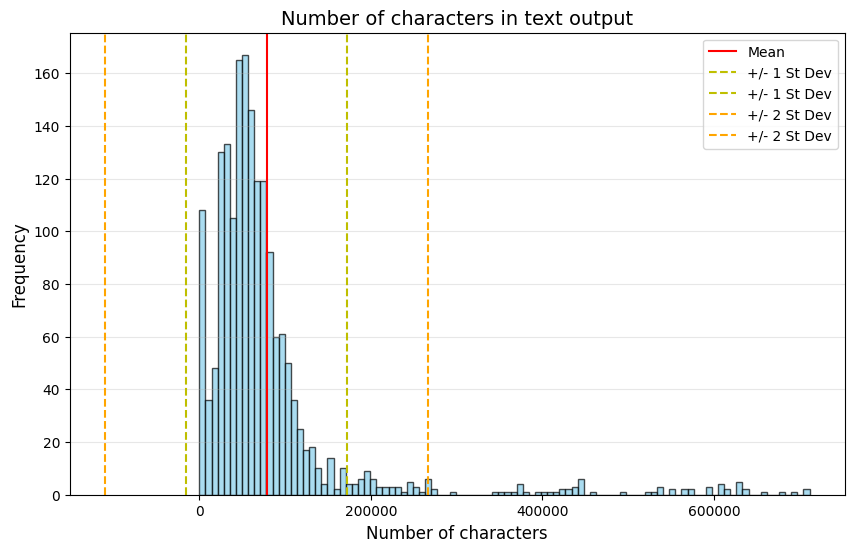

In [22]:
mean_text_len = text_len['text_output'].mean()
st_dev_text_len = text_len['text_output'].std()

fig = plot_utils.create_generic_histogram(text_len, 
                                          100, 
                                          "Number of characters in text output",
                                          "Number of characters",
                                          mean_text_len, st_dev_text_len)

plt.show()

**Outcome** - There are examples with very large texts. I have expected that the distribution would be gaussian, however the visual data represented by the histogram disproves that expectation. I suspect that long texts will result in less meaningful sentiment scores. 

In the following cells, I will attempt to perform cleaning of the text, as described.

In [23]:
verified_filing_data_clean['cleaned_text'] = (
    verified_filing_data_clean['text_output']
    .apply(nlp_utils.clean_for_finbert)
)

verified_filing_data_clean.to_csv(DATA_DIR / "verified_filing_data_clean_text.csv", index=False)

In [24]:
clean_text_len = pd.DataFrame(verified_filing_data_clean['cleaned_text'].str.len())
clean_text_len.describe().T

,count,mean,std,min,25%,50%,75%,max
cleaned_text,1795.0,56789.223398,79587.198575,179.0,23562.5,37847.0,60613.0,678581.0


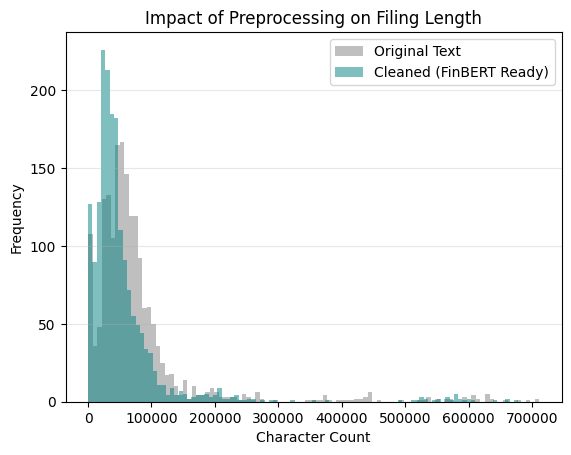

In [25]:
plt.hist(text_len, bins=100, alpha=0.5, label='Original Text', color='gray')
plt.hist(clean_text_len, bins=100, alpha=0.5, label='Cleaned (FinBERT Ready)', color='teal')
plt.title('Impact of Preprocessing on Filing Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Ouctome** - performing the text cleaning reduced the descriptive characteristics of the text, hopefully improving quality for obtaining sentiment scores. The data shifted to the left visibly.

#### 8. NLP text processing Source

For sentiment extraction, I utilized FinBERT (Araci, 2019), a domain-specific transformer model based on the BERT architecture. Unlike general-purpose language models, FinBERT was pre-trained on a massive corpus of financial communications, allowing it to accurately decode the nuanced language and 'tone' of corporate disclosures where standard models often fail.

Developed by Google in 2018, BERT (Bidirectional Encoder Representations from Transformers) improved natural language processing significantly when introduced.

#### 9. Methodology & Model Choice

To analyze the "Hard Data" provided in this repository, I utilized the FinBERT (`ProsusAI/finbert`) model—a pre-trained Natural Language Processing (NLP) model specifically fine-tuned for financial sentiment.

- **Task:** Classification of around **1,795** unique texts  
- **Processing:** Each text (avg. **7,333** tokens) will be split into overlapping **512-token** chunks.  
- **Aggregation:** The final score will be the mean average of all chunks within a single transcript, providing a global sentiment value between **-1** (Bearish) and **1** (Bullish).  

The cell below will provide an example of what I intend to do.

##### 9.1. Computational Hardware & Performance

Deep learning on large text blocks is computationally expensive. The results provided here will be generated using **GPU Acceleration** to ensure efficiency.

##### 9.2. Benchmark Comparison

If you choose to recalculate these scores using the provided script, please be aware of the following estimated processing times:

| Environment | Device Type | Avg. Time per Score | Total Time (1,795) |
|------------|-------------|---------------------|--------------------|
| Standard Laptop | Intel/AMD CPU | ~33.3 seconds | ~16.5 to 17 hours |
| High-End PC | NVIDIA GPU (CUDA) | ~0.9 - 1.0 seconds | ~30 minutes |
| Cloud (Google Colab) | Tesla T4 GPU | ~0.7-0.8 seconds | ~25 minutes |

**Instruction:** If running on a "regular" machine (CPU), ensure the laptop is plugged into a power source and "Sleep Mode" is disabled. The fans will likely run at maximum speed during this process.

Let's see the example cell:

In [26]:
# I will utilize a test sample dataframe for the illustration of the method implementation
verified_filing_data_clean_text = pd.read_csv(BASE_URL + "verified_filing_data_clean_text.csv")

test_sample_1 = pd.concat([
    verified_filing_data_clean_text[verified_filing_data_clean_text['Filing Type'] == '10-Q'].head(5),
    verified_filing_data_clean_text[verified_filing_data_clean_text['Filing Type'] == '8-K'].head(5)
]).reset_index(drop=True)

model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, ignore_mismatched_sizes=True)

device = 0 if torch.cuda.is_available() else -1 
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

sentiment_results = []

# for i, row in verified_filing_data_clean_text.iterrows():
for i, row in test_sample_1.iterrows():
    try:

        chunks = nlp_utils.classify_long_transcript_batched(row['cleaned_text'], tokenizer, nlp)
        score = nlp_utils.aggregate_sentiment(chunks)

        sentiment_results.append(score)

    except Exception as e:
        print(f"Error at row {i}: {e}")
        sentiment_results.append(0)


test_sample_1['sentiment_score'] = sentiment_results
# verified_filing_data_clean_text.to_csv(DATA_DIR / 'final_dataset_with_sentiment.csv', index=False)
test_sample_1

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,text_output,extraction_status,cleaned_text,sentiment_score
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,Item 2. \tManagement’s Discussion and Analysis...,SUCCESS,Item 2. Management’s Discussion and Analysis o...,-0.005772
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,SUCCESS,Item 2. MANAGEMENT’S DISCUSSION AND ANALYSIS O...,-0.806065
2,2552121,Walt Disney Co,DIS,1744489,2026-02-01,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/174448...,2026-02-02,True,True,0001744489-26-000019,MANAGEMENT’S DISCUSSION AND ANALYSIS OF\n\nFIN...,SUCCESS,MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANC...,-0.049975
3,2551537,Apple Inc.,AAPL,320193,2026-01-29,10-Q,26.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/320193...,2026-01-30,True,True,0000320193-26-000006,Item 2. Management’s Discussion and Analysi...,SUCCESS,Item 2. Management’s Discussion and Analysis o...,-0.406248
4,2551531,VISA INC.,V,1403161,2026-01-29,10-Q,30.12.2025,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/140316...,2026-01-30,True,True,0001403161-26-000045,Table of Contents\n\nITEM 2.Management’s Discu...,SUCCESS,Table of Contents ITEM 2.Management’s Discussi...,0.057300
5,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,Document\n\nNVIDIA Announces Financial Results...,SUCCESS,Document NVIDIA Announces Financial Results fo...,0.279819
6,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,Document\n\nExhibit 99.1\n\nSalesforce Deliver...,SUCCESS,Document Exhibit 99.1 Salesforce Delivers Reco...,0.118013
7,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,Document\n\n\n ...,SUCCESS,Document Walmart reports Q4 results •Revenue g...,0.136180
8,2559317,DEERE & CO,DE,315189,2026-02-18,8-K,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-19,True,True,0001104659-26-017239,Exhibit 99.1\n(Furnished herewith)\n​\n\n\nNew...,SUCCESS,Exhibit 99.1 (Furnished herewith) ​ News Relea...,-0.031144
9,2558457,FIRSTENERGY CORP,FE,1031296,2026-02-16,8-K,30.12.2025,2025.0,4.0,https://www.sec.gov/Archives/edgar/data/103129...,2026-02-17,True,True,0001031296-26-000041,Document\n\nExhibit 99.1\n\n\nFirstEnergy Corp...,SUCCESS,Document Exhibit 99.1 FirstEnergy Corp. For Re...,0.237013


Below is the code to run sentiment scoring on the full dataset. I ran it to complete the data set. However, I used T4 runtime in Google Colab to process the data in under 1 hour. I will leave the code commented, while the calculated data is available with the repo on Google Cloude Storage.

In [27]:
# The code to obtain sentiment scores on all rows in the dataset. I will leave in commented state.

# verified_filing_data_clean_text = pd.read_csv(BASE_URL + "verified_filing_data_clean_text.csv")

# model_name = "ProsusAI/finbert"
# tokenizer = BertTokenizer.from_pretrained(model_name)
# model = BertForSequenceClassification.from_pretrained(model_name, ignore_mismatched_sizes=True)

# device = 0 if torch.cuda.is_available() else -1 
# nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# sentiment_results = []
# checkpoint_path = 'static_data/final_dataset_with_sentiment_checkpoint.csv', index=False)

# for i, row in tqdm(verified_filing_data_clean_text.iterrows(), total=len(verified_filing_data_clean_text)):
#     try:
#         text_input = str(row['cleaned_text']) if pd.notnull(row['cleaned_text']) else ""

#         if text_input.strip() == "":
#             sentiment_results.append(0)
#             continue

#         chunks = nlp_utils.classify_long_transcript_batched(text_input, tokenizer, nlp)
#         score = nlp_utils.aggregate_sentiment(chunks)
#         sentiment_results.append(score)

#     except Exception as e:
#         print(f"Error at row {i}: {e}")
#         sentiment_results.append(0)

#     if (i + 1) % 100 == 0:
#         # Temporary save so you don't lose progress
#         temp_df = verified_filing_data_clean_text.iloc[:len(sentiment_results)].copy()
#         temp_df['sentiment_score'] = sentiment_results
#         temp_df.to_csv(checkpoint_path, index=False)


# verified_filing_data_clean_text['sentiment_score'] = sentiment_results
# verified_filing_data_clean_text.to_csv('DATA_DIR/final_dataset_with_sentiment.csv', index=False)
# verified_filing_data_clean_text

#### 10. Let's now explore the sentiment scores.

The data is available on google cloud storage, or alternatively if the full route is taken - in the static data dir of the project.

In [28]:
final_dataset_with_sentiment = pd.read_csv(BASE_URL + "final_dataset_with_sentiment.csv")

# Alternatively, from our local static_data  folder to follow the original path of data obtaining and handling
# filing_data = pd.read_csv("DATA_DIR / final_dataset_with_sentiment.csv")

final_dataset_with_sentiment

,Filing ID,Company,Ticker,CIK,Filing Date,Filing Type,Period End,Fiscal Year,Fiscal Period,SEC Link,Calcbench Published,Data,is_verified_signal,accession,extraction_status,sentiment_score
0,2568709,ORACLE CORP,ORCL,1341439,2026-03-10,10-Q,27.2.2026,2026.0,3.0,https://www.sec.gov/Archives/edgar/data/134143...,2026-03-11,True,True,0001193125-26-101045,SUCCESS,-0.005772
1,2563404,DEERE & CO,DE,315189,2026-02-25,10-Q,31.1.2026,2026.0,1.0,https://www.sec.gov/Archives/edgar/data/315189...,2026-02-26,True,True,0001104659-26-020158,SUCCESS,-0.806066
2,2562654,NVIDIA CORP,NVDA,1045810,2026-02-24,8-K,24.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104581...,2026-02-25,True,True,0001045810-26-000019,SUCCESS,0.279819
3,2562300,"Salesforce, Inc.",CRM,1108524,2026-02-24,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/110852...,2026-02-25,True,True,0001108524-26-000056,SUCCESS,0.118013
4,2559386,Walmart Inc.,WMT,104169,2026-02-18,8-K,30.1.2026,2026.0,4.0,https://www.sec.gov/Archives/edgar/data/104169...,2026-02-19,True,True,0000104169-26-000032,SUCCESS,0.136180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,1568535,TARGET CORP,TGT,27419,2020-05-19,8-K,1.5.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/27419/...,2020-05-20,True,True,0000027419-20-000011,SUCCESS,-0.130304
1791,1568023,Walmart Inc.,WMT,104169,2020-05-18,8-K,29.4.2020,2021.0,1.0,https://www.sec.gov/Archives/edgar/data/104169...,2020-05-19,True,True,0000104169-20-000016,SUCCESS,0.156512
1792,1560989,UNITED PARCEL SERVICE INC,UPS,1090727,2020-05-07,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/109072...,2020-05-08,True,True,0001090727-20-000023,SUCCESS,-0.495376
1793,1559527,JPMORGAN CHASE & CO,JPM,19617,2020-05-06,10-Q,30.3.2020,2020.0,1.0,https://www.sec.gov/Archives/edgar/data/19617/...,2020-05-07,True,True,0000019617-20-000299,SUCCESS,-0.010477


Let's obtain the sentiment score descriptive statistics:

In [29]:
pd.DataFrame(final_dataset_with_sentiment['sentiment_score']).describe().T

,count,mean,std,min,25%,50%,75%,max
sentiment_score,1795.0,-0.044907,0.199955,-0.965393,-0.152236,-0.009752,0.078337,0.604251


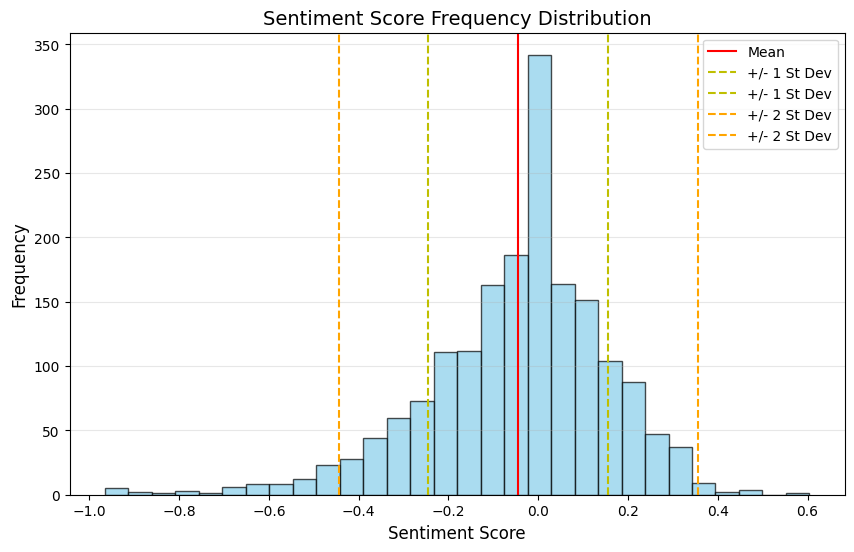

In [30]:
mean_sent_score = final_dataset_with_sentiment['sentiment_score'].mean()
st_dev_sent_score = final_dataset_with_sentiment['sentiment_score'].std()

fig = plot_utils.create_generic_histogram(final_dataset_with_sentiment['sentiment_score'], 
                                          30, 
                                          "Sentiment Score Frequency Distribution",
                                          'Sentiment Score',
                                          mean_sent_score, st_dev_sent_score)
                                          

plt.show()

**Outcome** - Sentiment scores are centered near zero with slight negative skew.

Interpretation:
- Regulatory texts tend to be neutral or conservative. I expected positive bias or as I called it management bias. It appears that management bias is showing in a more conservative approach. 
- Extreme positive sentiment is rare
- Distribution supports validity of scoring approach

#### 11. Combine sentinment score and stock returns datasets, perform exploration


In [31]:
stock_returns = pd.read_csv(BASE_URL + "stock_returns_static_dataset.csv")
stock_returns

,Date,AAPL,GOOG,MSFT,NVDA,JPM,BAC,F,UPS,WMT,...,CVX,CAT,DE,LMT,AMD,INTC,ORCL,CRM,CB,PG
0,2016-04-01,0.009133,0.006636,0.006137,0.014489,0.010916,0.002954,-0.030077,-0.004943,0.008288,...,-0.012022,0.003261,-0.006385,0.007242,-0.007042,0.003086,0.006092,0.025409,0.014167,0.014714
1,2016-04-04,0.010221,-0.006180,-0.002523,-0.009729,-0.003877,-0.003694,-0.023167,-0.000668,0.000579,...,-0.008844,-0.014032,-0.007874,0.004561,0.000000,-0.013965,-0.002189,-0.000528,-0.002154,-0.003838
2,2016-04-05,-0.011859,-0.010101,-0.015820,-0.001397,-0.014291,-0.023971,-0.002347,-0.009195,-0.006680,...,-0.008167,-0.006360,0.002237,0.006626,-0.025046,-0.003130,-0.013235,-0.014774,-0.022136,-0.000601
3,2016-04-06,0.010418,0.010637,0.010212,0.001397,0.007681,0.006047,0.003908,0.007191,0.005811,...,0.023146,-0.000266,0.003543,0.004467,0.014389,0.005627,0.005413,0.013319,0.010458,0.007786
4,2016-04-07,-0.022051,-0.007282,-0.012046,-0.010389,-0.025662,-0.032162,-0.023679,-0.006518,-0.011949,...,-0.000527,-0.014057,-0.002098,-0.000662,-0.058840,-0.016660,-0.019326,-0.003446,-0.013175,-0.006824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,2026-03-24,0.000596,-0.033392,-0.027154,-0.002508,0.008552,0.012963,0.006780,0.007853,0.010957,...,0.007670,0.021054,0.024288,-0.009915,0.013185,0.001136,-0.048113,-0.064327,-0.002331,-0.005781
2509,2026-03-25,0.003887,0.001348,-0.004571,0.019668,0.010275,0.012592,-0.014462,-0.000711,0.008241,...,-0.007962,0.003357,-0.008665,0.022733,0.070041,0.068418,-0.007301,-0.005809,-0.007398,0.005295
2510,2026-03-26,0.001068,-0.031037,-0.013759,-0.042530,-0.012809,-0.010517,-0.006016,-0.008884,-0.007177,...,0.012787,-0.022290,0.005521,0.005002,-0.077862,-0.067510,-0.022229,0.020022,0.003398,-0.010477
2511,2026-03-27,-0.016305,-0.025177,-0.025460,-0.021963,-0.030707,-0.026679,-0.020027,-0.028083,0.005794,...,0.016041,-0.011140,-0.025354,-0.018486,-0.008774,-0.022241,-0.022304,-0.034693,-0.016227,0.002034


In [32]:
stock_returns_long = stock_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='log_return')
stock_returns_long

,Date,Ticker,log_return
0,2016-04-01,AAPL,0.009133
1,2016-04-04,AAPL,0.010221
2,2016-04-05,AAPL,-0.011859
3,2016-04-06,AAPL,0.010418
4,2016-04-07,AAPL,-0.022051
...,...,...,...
75385,2026-03-24,PG,-0.005781
75386,2026-03-25,PG,0.005295
75387,2026-03-26,PG,-0.010477
75388,2026-03-27,PG,0.002034


In [33]:
sentiment_data = pd.read_csv(BASE_URL + "final_dataset_with_sentiment.csv")
sentiment_long = sentiment_data[['Filing Date', 'Ticker', 'sentiment_score']]
sentiment_long.columns = ['Date', 'Ticker', 'sentiment_score']
sentiment_long

,Date,Ticker,sentiment_score
0,2026-03-10,ORCL,-0.005772
1,2026-02-25,DE,-0.806066
2,2026-02-24,NVDA,0.279819
3,2026-02-24,CRM,0.118013
4,2026-02-18,WMT,0.136180
...,...,...,...
1790,2020-05-19,TGT,-0.130304
1791,2020-05-18,WMT,0.156512
1792,2020-05-07,UPS,-0.495376
1793,2020-05-06,JPM,-0.010477


In [34]:
merged_return_sentiment_data = pd.merge(stock_returns_long, sentiment_long, on=['Date', 'Ticker'], how='left')
merged_return_sentiment_data = merged_return_sentiment_data.sort_values(['Ticker', 'Date'])
ret_col = 'log_return' if 'log_return' in merged_return_sentiment_data.columns else 'Return'
merged_return_sentiment_data['target_log_return_t1'] = merged_return_sentiment_data.groupby('Ticker')[ret_col].shift(-1)
merged_return_sentiment_data

,Date,Ticker,log_return,sentiment_score,target_log_return_t1
0,2016-04-01,AAPL,0.009133,NaN,0.010221
1,2016-04-04,AAPL,0.010221,NaN,-0.011859
2,2016-04-05,AAPL,-0.011859,NaN,0.010418
3,2016-04-06,AAPL,0.010418,NaN,-0.022051
4,2016-04-07,AAPL,-0.022051,NaN,0.001105
...,...,...,...,...,...
50334,2026-03-24,XOM,0.026034,NaN,-0.012902
50335,2026-03-25,XOM,-0.012902,NaN,0.013204
50336,2026-03-26,XOM,0.013204,NaN,0.033057
50337,2026-03-27,XOM,0.033057,NaN,0.002803


In [35]:
return_col = 'log_return'
return_t_plus_one = 'target_log_return_t1'
sentiment_col = 'sentiment_score'

cleaned_merged_return_sentiment_data = merged_return_sentiment_data.dropna(
    subset=[sentiment_col, return_col, return_t_plus_one]
).copy()

cleaned_merged_return_sentiment_data.to_csv(DATA_DIR / "cleaned_merged_return_sentimet_data.csv")
cleaned_merged_return_sentiment_data

,Date,Ticker,log_return,sentiment_score,target_log_return_t1
16,2016-04-25,AAPL,-0.005694,0.156532,-0.006971
18,2016-04-27,AAPL,-0.064622,-0.200405,-0.031043
79,2016-07-25,AAPL,-0.013469,0.119829,-0.006907
81,2016-07-27,AAPL,0.062940,-0.314025,0.013411
143,2016-10-24,AAPL,0.008965,0.000000,0.005087
...,...,...,...,...,...
50047,2025-01-30,XOM,0.008248,0.005217,-0.025325
50110,2025-05-01,XOM,0.001419,-0.054214,0.004057
50172,2025-07-31,XOM,-0.002326,0.034461,-0.018077
50236,2025-10-30,XOM,-0.015229,-0.017070,-0.002881


Let's create scatterplots:

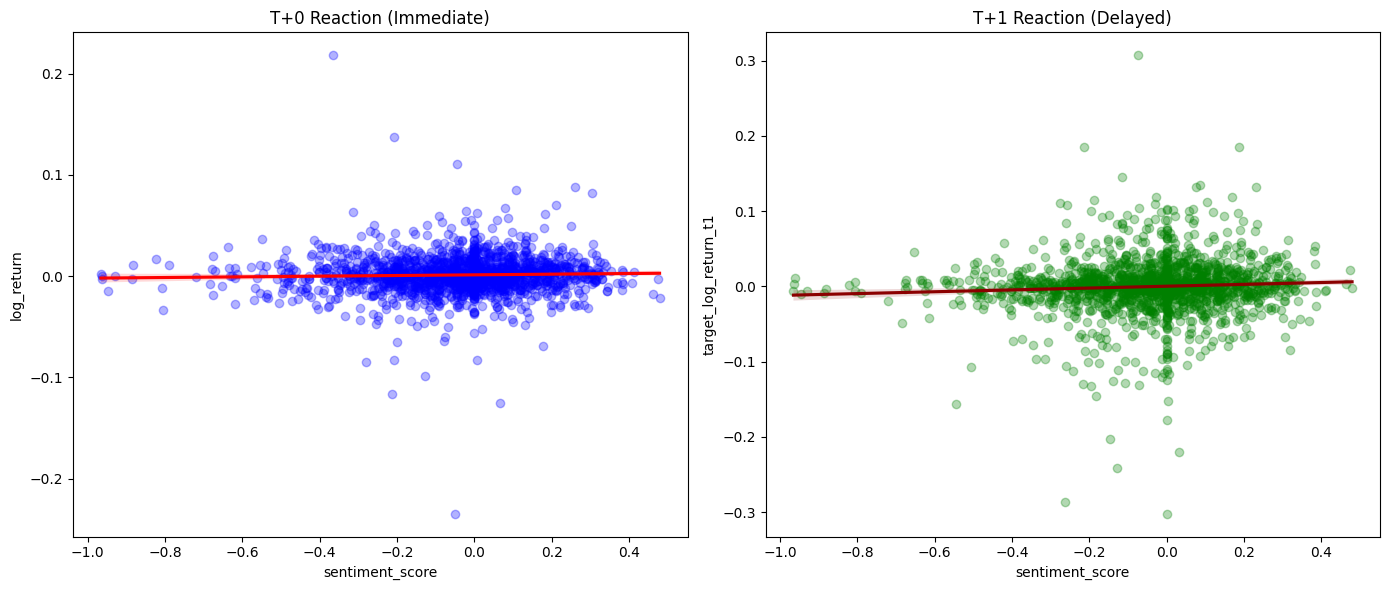

In [36]:
# Initialize the subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Immediate Reaction
sns.regplot(x='sentiment_score', y='log_return', data=cleaned_merged_return_sentiment_data, ax=axes[0], 
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red'})
axes[0].set_title('T+0 Reaction (Immediate)')

# Plot 2: Delayed Reaction
sns.regplot(x='sentiment_score', y='target_log_return_t1', data=cleaned_merged_return_sentiment_data, ax=axes[1], 
            scatter_kws={'alpha':0.3, 'color':'green'}, 
            line_kws={'color':'darkred'})
axes[1].set_title('T+1 Reaction (Delayed)')

plt.tight_layout()
plt.show()

The scatter plots do not provide a great visual story to the data.

**The "Story" Revealed: Binned Sentiment Analysis**

Instead of looking at 1,670 dots trying to discern relationship and noise, I will group the filings into 10 buckets (Deciles) based on their sentiment score—from worst (Decile 0) to best (Decile 9)—and calculate the average return for each bucket.

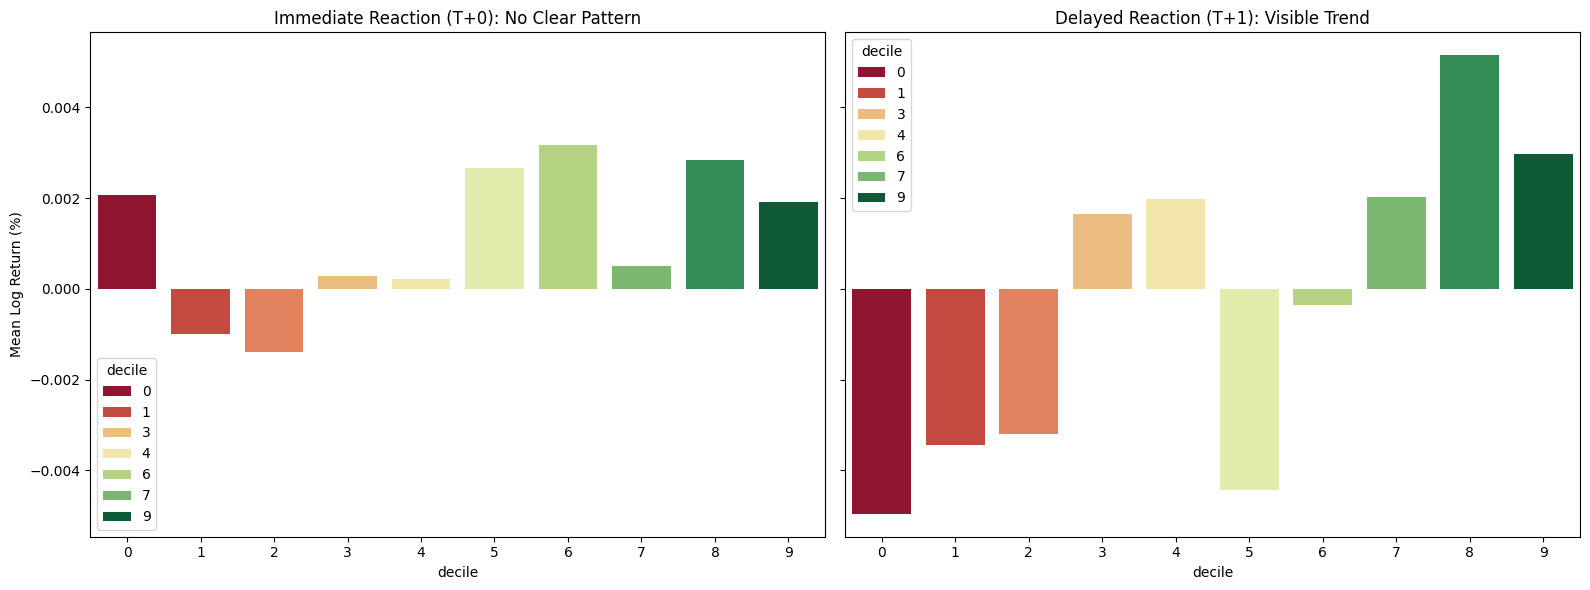

In [37]:
cleaned_merged_return_sentiment_data['decile'] = pd.qcut(cleaned_merged_return_sentiment_data['sentiment_score'], 10, labels=False)

story_df = cleaned_merged_return_sentiment_data.groupby('decile')[['log_return', 'target_log_return_t1']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.barplot(x=story_df.index, y=story_df['log_return'], hue=story_df.index, palette='RdYlGn', ax=axes[0])
axes[0].set_title("Immediate Reaction (T+0): No Clear Pattern")
axes[0].set_ylabel("Mean Log Return (%)")

sns.barplot(x=story_df.index, y=story_df['target_log_return_t1'], hue=story_df.index, palette='RdYlGn', ax=axes[1])
axes[1].set_title("Delayed Reaction (T+1): Visible Trend")

plt.tight_layout()
plt.show()

Objective Interpretation:

1. **The T+1 Drift**: The "story" is in the extremes. The most negative filings (Decile 0) result in a -0.50% average loss the next day, while the highly positive filings (Decile 8) result in a +0.52% average gain.
   
2. **Predictive Spread**: There is a 1.02% spread between the best and worst news categories. For a single-day prediction, this is a fairly large "alpha" signal in my finance experience.

3. **T+0 is Messy**: I see that for $T+0$ (Same Day), Decile 0 (worst) actually has a positive return (+0.21%). This visually explains why we failed to reject $H_0$ for the same day — the market simply hasn't received and/or processed the information yet.

#### 12. Hypothesis forming and testing

**Methodology**

The null hypothesis states that the obtained sentiment scores have no relationship to stock returns. The alternative hypothesis states that we can obtained meaningfull relationship information between the sentiment scores and the stock returns.

Hypothesis testing on all tests is conducted at $\alpha = 0.01$.

Tests include:
- Pearson correlation
- OLS regression
- ANOVA for categorical signals

In [38]:
ALPHA = 0.01

def perform_hypothesis_test(df, target_col, label):
    print(f"\n{'='*20} Analysis for {label} {'='*20}")
    
    r, p_corr = stats.pearsonr(df['sentiment_score'], df[target_col])
    
    X = sm.add_constant(df['sentiment_score']) 
    y = df[target_col]
    model = sm.OLS(y, X).fit()
    
    p_value = model.pvalues['sentiment_score']
    
    print(f"Pearson Correlation (r): {r:.4f}")
    print(f"Regression P-value:      {p_value:.4f}")
    
    if p_value < ALPHA:
        print(f"RESULT: Reject H0 (p < {ALPHA}).")
        print(f"CONCLUSION: Sentiment score adds SIGNIFICANT information value to {label} price.")
    else:
        print(f"RESULT: Fail to Reject H0 (p >= {ALPHA}).")
        print(f"CONCLUSION: Sentiment score adds NO significant information value to {label} price.")

# Run the test for T+0
perform_hypothesis_test(cleaned_merged_return_sentiment_data, 'log_return', 'T+0 (Same Day)')

# Run the test for T+1
perform_hypothesis_test(cleaned_merged_return_sentiment_data, 'target_log_return_t1', 'T+1 (Next Day)')


==================== Analysis for T+0 (Same Day) ====================
Pearson Correlation (r): 0.0333
Regression P-value:      0.1732
RESULT: Fail to Reject H0 (p >= 0.01).
CONCLUSION: Sentiment score adds NO significant information value to T+0 (Same Day) price.

==================== Analysis for T+1 (Next Day) ====================
Pearson Correlation (r): 0.0648
Regression P-value:      0.0081
RESULT: Reject H0 (p < 0.01).
CONCLUSION: Sentiment score adds SIGNIFICANT information value to T+1 (Next Day) price.


Here is a breakdown of the statistical procedure I followed. Since the data showed a significant result for $T+1$ but not for $T+0$, understanding these metrics is key to our final report.

##### 1. The Type of Analysis: Simple Linear Regression
To test the hypotheses, I perform a **Simple Linear Regression**. 

In this analysis, I test whether the Stock Return ($Y$) can be predicted by the Sentiment Score ($X$). The model looks like this:
$$\text{Return} = \beta_0 + \beta_1(\text{Sentiment}) + \epsilon$$

* **$\beta_1$ (The Coefficient):** This is the most important number. It tells us the "slope." If $\beta_1$ is positive, it means higher sentiment leads to higher returns.
* **The Analysis:** We are testing whether $\beta_1$ is significantly different from zero.

##### 2. The Hypotheses (at $\alpha = 0.01$)
I point emphasize that $H_0$ is the "status quo" (nothing is happening).

**For $T+0$ (Same Day):**
* **$H_0$:** Sentiment score adds no information ($\beta_1 = 0$).
* **$H_1$:** Sentiment score adds significant value ($\beta_1 \neq 0$).
* **Result:** Since the resulting p-value was **$0.173$**, I **fail to reject $H_0$**. The sentiment does not provide a tradable signal on the same day.

**For $T+1$ (Next Day):**
* **$H_0$:** Sentiment score adds no information ($\beta_1 = 0$).
* **$H_1$:** Sentiment score adds significant value ($\beta_1 \neq 0$).
* **Result:** Since the resultinh p-value was **$0.008$**, which is less than the $0.01$ limit, I **reject $H_0$**. It appears that there is a statistically significant reaction result in stock return .

##### 3. Explanation of the Pearson Metric
The **Pearson Correlation Coefficient ($r$)** measures the strength and direction of a linear relationship between two variables.

* **Range:** It goes from **$-1$** (perfect negative relationship) to **$+1$** (perfect positive relationship). **$0$** means no relationship at all.
* **The observed $T+1$ Result ($r = 0.064$):** This is a "weak positive" correlation. In finance, thousands of factors move a stock every day, and therefore a correlation of $0.064$ appeared statistically significant in this case. It is possible that we can consider it as a real, usable "alpha" (signal).

##### 4. How do I determine the P-value?
The p-value is calculated based on the **t-statistic**. Here is how I applied it in the performed regression:

1. **Calculate the Standard Error:** How much does the sentiment effect vary across all cases?
2. **Calculate the t-stat:** - divide the Coefficient by the Standard Error ($t = \beta_1 / SE$).
3. **Find the P-value:** The p-value is the probability of seeing a t-stat this large if the true relationship was actually zero.

**Think of the P-value as a "Surprise Meter":**
* If $p = 0.173$ ($T+0$), I am not surprised. A result like that can be interpreted as lack of contribution of the sentiment score to the daily return, or a random chance. This may be due to the fact that the majority of such filings occur in after market hours and I cannot test this. This is why I included the next day return in the situation.
* If $p = 0.008$ ($T+1$), This result appears to show that there is less than a 1% chance that this pattern happened by accident. Therefore, we conclude the sentiment shows the relationship between the sentiment score of the 8-K or 10-Q filing regarding company earnings can influence the result in the following day with statistical significance.

##### Summary:
"Based on a Simple Linear Regression and Pearson Correlation analysis, I fail to reject the null hypothesis for $T+0$ ($p > 0.01$). However, I reject the null hypothesis for $T+1$ ($p < 0.01$), concluding that SEC filing sentiment has a delayed information value that is priced into the stock market on the following trading day."

#### 13. Heteroscedasticity and Cross-Stock Dependence

However, there is a problem in statistics, which is valid also in financial quantitative work called **heteroscedasticity** or unequal variance.

##### The Risk of Cross-Stock Dependence

If multiple stocks are combined into a single regression without normalization, it is possible that we can observe:

- **Volatility Bias:**  
  A stable stock (e.g., $XOM$) might move $1\%$ on a "big" news day, while a volatile stock (e.g., $NVDA$) moves $5\%$ on a "normal" day.

- **Weighted Influence:**  
  In the current regression, high-volatility stocks "pull" the regression line much more strongly than stable ones. This biases the results toward the behavior of the riskiest companies in the dataset.

- **Violation of OLS Assumptions:**  
  As discussed in the lectures, regression assumes that error terms have constant variance. Mixing raw returns from stocks like $AAPL$ and $NVDA$ violates this assumption because their natural variances differ significantly.

##### The way to control this bias: Z-Score Normalization (Standardization)

The standard approach is to scale returns by each ticker’s own volatility. This transforms returns into **standard deviations from the mean**, making movements comparable across stocks.

For example:
- A $1\%$ move in a stable stock can become equivalent to a $4\%$ move in a volatile stock after normalization.

$$
z_{i,t} = \frac{r_{i,t} - \mu_i}{\sigma_i}
$$

Where:
- $r_{i,t}$: Log return for stock $i$ at time $t$  
- $\mu_i$: Average return for stock $i$  
- $\sigma_i$: Standard deviation (volatility) for stock $i$  

##### Implementation

I will apply log return normalization **per ticker** using a `groupby` operation before repeating the analysis of hypothesis testing, this time applying the .

In [39]:
df = cleaned_merged_return_sentiment_data
# 1. Normalize Log Returns per Ticker
# This ensures every stock has a Mean of 0 and Standard Deviation of 1
df['normalized_return_T0'] = df.groupby('Ticker')['log_return'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df['norm_target_log_return_t1'] = df.groupby('Ticker')['target_log_return_t1'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# 2. Re-run the Regression with Normalized Data
import statsmodels.api as sm

X = sm.add_constant(df['sentiment_score'])
model_normalized_t1 = sm.OLS(df['norm_target_log_return_t1'], X).fit()
model_normalized_t0 = sm.OLS(df['normalized_return_T0'], X).fit()

print(f"Normalized T+1 P-value: {model_normalized_t1.pvalues['sentiment_score']:.4f}")
print(f"Normalized Coefficient T+1: {model_normalized_t1.params['sentiment_score']:.4f}")
print(f"Normalized T P-value: {model_normalized_t0.pvalues['sentiment_score']:.4f}")
print(f"Normalized Coefficient T: {model_normalized_t0.params['sentiment_score']:.4f}")

Normalized T+1 P-value: 0.0153
Normalized Coefficient T+1: 0.2928
Normalized T P-value: 0.4354
Normalized Coefficient T: 0.0942


This became a critical turning point for this research chain. 

By applying normalization, I tried to remove a possible **"Volatility Bias"** where high-variance stocks were influencing the statistical hypothesis-testing results to a greater extent.

In my first (raw data for returns) analysis, the $T+1$ p-value was $0.0081$, which allowed me to claim a significant relationship at the $0.01$ level. 

After normalizing to ensure no single stock's volatility dominated the model, the p-value rose to $0.0153$. 

The risk of cross-stock dependence was real. The non-normalized model was likely being influenced by the few stocks with high volatility, where large moves happened to align with sentiment. 

Once the playing field is leveled and giving Apple and Exxon equal "weight" in standard deviations, the signal weakened.

At my chosen significance level of $\alpha = 0.01$, I no longer have a statistically significant result. According to the strict rules of hypothesis testing, I must state that I do not have enough evidence to reject $H_0$. Therefore, the sentiment score does not add significant information value to the price at the $99\%$ confidence level once stock-specific volatility is accounted for. 

I could argue that $0.0153$ is significant at the $0.05$ level ($95\%$ confidence). However, normalization of returns revealed that my previous "significant" result was partially an artifact of cross-stock volatility differences. The signal I tested for is weaker than I wanted. It is significant at $5\%$, but it fails my $1\%$ "Stress Test."

##### Multi-Horizon Testing

I will evaluate returns over multiple horizons (t+1, t+2, t+3, t+5).

Purpose:
- Detect delayed market reactions
- Evaluate persistence of sentiment effects

First I will prepare the data and drop `NaN` values

In [40]:
targets = ["target_log_return_t2", "target_log_return_t3", "target_log_return_t5"]
cleaned_merged_return_sentiment_data = sig_utils.add_multi_day_targets(cleaned_merged_return_sentiment_data)
cleaned_merged_return_sentiment_data = sig_utils.normalize_targets_per_ticker(cleaned_merged_return_sentiment_data, targets)

cleaned_merged_return_sentiment_data

,Date,Ticker,log_return,sentiment_score,target_log_return_t1,decile,normalized_return_T0,norm_target_log_return_t1,target_log_return_t2,target_log_return_t3,target_log_return_t5,norm_target_log_return_t2,norm_target_log_return_t3,norm_target_log_return_t5
16,2016-04-25,AAPL,-0.005694,0.156532,-0.006971,8,-0.414032,-0.478428,-0.078091,-0.015151,-0.008814,-2.881576,-0.854075,-0.645562
18,2016-04-27,AAPL,-0.064622,-0.200405,-0.031043,1,-3.280137,-1.301245,0.049471,0.058436,0.115002,1.391082,1.418391,2.217572
79,2016-07-25,AAPL,-0.013469,0.119829,-0.006907,8,-0.792219,-0.476220,0.071905,0.069277,0.148663,2.142510,1.753201,2.995959
81,2016-07-27,AAPL,0.062940,-0.314025,0.013411,0,2.924141,0.218295,0.006337,0.065531,0.092047,-0.053668,1.637509,1.686768
143,2016-10-24,AAPL,0.008965,0.000000,0.005087,5,0.298920,-0.066239,0.056566,0.076758,0.077919,1.628742,1.984216,1.360060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49734,2023-10-30,XOM,0.003122,-0.331529,-0.000284,0,0.095339,0.243509,-0.001783,-0.015709,-0.006690,-0.359335,-1.153599,-0.757141
49798,2024-02-01,XOM,-0.004093,0.015876,-0.004110,6,-0.438661,0.051258,-0.011615,-0.010844,-0.001177,-0.947881,-0.901087,-0.516408
49856,2024-04-25,XOM,0.002310,-0.011835,-0.028168,4,0.035288,-1.157361,-0.013155,-0.004907,-0.005814,-1.040031,-0.592876,-0.718887
49923,2024-08-01,XOM,-0.013926,0.025452,-0.000599,6,-1.166345,0.227671,0.009019,0.010438,-0.007117,0.287250,0.203674,-0.775809


Next, perform correlation analysis:

In [41]:
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
indicators = ['sentiment_score']

for target in targets:
    print(f"\nCorrelation Results for {target}:")
    sig_utils.run_individual_hypothesis_tests(cleaned_merged_return_sentiment_data, target, indicators)


Correlation Results for norm_target_log_return_t1:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
sentiment_score |     0.054318 | 3.4215e-02 | NO

Correlation Results for norm_target_log_return_t2:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
sentiment_score |     0.009883 | 7.0024e-01 | NO

Correlation Results for norm_target_log_return_t3:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
sentiment_score |     0.022851 | 3.7331e-01 | NO

Correlation Results for norm_target_log_return_t5:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
sentiment_score |     0.028594 | 2.6523e-01 | NO


**Outcome**
- The sample decreased to 1520 rows. The p-value weakened firther for T+1
- Slight increase in correlation at longer horizons
- No statistical significance at α = 0.01

**Conclusion**: Weak evidence of delayed effects, but not robust. The null hypothesis cannot be rejected for any time of the time horizons tested.

Then, perform multivariate analysis:

In [43]:
signals = ['sentiment_score']
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
for target in targets:
    
    result = sig_utils.run_multivariate_anova(cleaned_merged_return_sentiment_data, target, signals)
    print(f"\nANOVA Results for {target}:")
    print(result)
    


ANOVA Results for norm_target_log_return_t1:
         Indicator  F_Statistic  P_Value  Reject_H0_01
0  sentiment_score          NaN      NaN         False

ANOVA Results for norm_target_log_return_t2:
         Indicator  F_Statistic  P_Value  Reject_H0_01
0  sentiment_score          NaN      NaN         False

ANOVA Results for norm_target_log_return_t3:
         Indicator  F_Statistic  P_Value  Reject_H0_01
0  sentiment_score          NaN      NaN         False

ANOVA Results for norm_target_log_return_t5:
         Indicator  F_Statistic  P_Value  Reject_H0_01
0  sentiment_score          NaN      NaN         False


D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\src\signal_testing_utils\signal_testing_utils.py:199: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = st.f_oneway(group_neg, group_neu, group_pos)
D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\src\signal_testing_utils\signal_testing_utils.py:199: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = st.f_oneway(group_neg, group_neu, group_pos)
D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\src\signal_testing_utils\signal_testing_utils.py:199: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requir

##### Categorical Signal Results

ANOVA results show no statistically significant differences across sentiment groups. These results do not point to any relationships, which can contain predictive power in order to generate stock trading signals

Conclusion: Discretizing sentiment does not improve predictive power.

#### 15. Conclusion

This portion of the project was set out to explore whether textual sentiment extracted from corporate earnings disclosures at the SEC can provide statistically and economically meaningful signals for equity price movements. The approach combines data engineering, Natural Language Processing (NLP), and statistical analysis within a unified framework.

From a methodological perspective, the project is grounded in standard quantitative finance techniques:
- A clearly defined hypothesis (sentiment → returns)
- A structured data pipeline (SEC filings → cleaned text → NLP → signal)
- Application of a domain-specific NLP model (FinBERT)
- Statistical testing via linear regression and correlation analysis
- Time separation of effects (T+0, T+1, T+2, T+3, T+5)

The results indicate a **statistically significant relationship for T+1** based on raw earnings, suggesting a slightly delayed market reaction to information embedded in filings. This may also be due to the fact that many earnings reports are filed in after-market hours and it is not possible for the market to absob this information on the same day.

However, no significant effect is observed when the results are normallized for controlling the possible volatility bias. Thus, I am not able to reject the null hypothesis that earnings report filings have no predictive value to stock returns. The statistic metrics improve between T+1 to T+5, which aligns with the hypothesis of gradual information absorption rather than immediate efficiency. However, none of the resulst were significant and **I cannot reject the null hypothesis**. 

##### Data Choice and Limitations

The original intention of this part of the project was to utilize **earnings call transcripts**, which are generally richer in tone, forward-looking statements, and management nuance. From a research standpoint, I expect that this would likely provide a stronger and more expressive sentiment signal.

However, a critical constraint emerged:

- Publicly available transcript datasets (e.g., Kaggle, Hugging Face) are often **scraped and redistributed in violation of source terms**
- Primary providers (e.g., Bloomberg, Refinitiv, Seeking Alpha APIs) operate behind **strict paywalls and licensing restrictions**

Given these legal and ethical considerations, the project pivoted toward **SEC filings (8-K exhibits and 10-Q MD&A sections)** as a compliant and reproducible data source. While this ensures transparency and legality, it introduces limitations:
- More formal and curated language
- Potential management bias
- Lower signal variability compared to live transcripts

##### Critical Methodological Considerations

While the framework is robust as a first-order analysis, several important limitations must be acknowledged:

1. **Omitted Variable Bias**  
   The regression model does not control for key drivers such as market returns, sector effects, or volatility regimes, which may bias the estimated relationship.

2. **Timing and Information Release Risk**  
   Precise alignment between filing release time and market data is critical. Any misalignment may introduce look-ahead bias.

3. **Multiple Hypothesis Testing**  
   Testing across multiple horizons increases the risk of false positives without formal correction.

4. **Sentiment Aggregation Simplification**  
   Averaging sentiment across text chunks assumes equal importance of all content, which may dilute meaningful signals and distort the result. 

5. **Data Source Bias**  
   SEC filings differ fundamentally from earnings calls in tone and informational content, potentially limiting predictive power. These texts were used as a fall back option due to unavailability of official and legally obtained data sets for earnings calls. 

##### Final Direction of the Project

Despite these limitations, the project establishes a **valid and operational signal extraction pipeline**, which is the primary objective at this stage.

In the final chapter, I will extend the analysis beyond statistical relationships and into **portfolio-level application**:

- Construct a **virtual trading strategy** based on:
  - Additional time-series signals derived from price behavior
- Compare performance against:
  - A **baseline optimal (buy-and-hold) portfolio**, constructed at a fixed starting point
- Evaluate over a **~5-year historical period**

The goal is to assess whether:
> A signal-driven, actively managed strategy can outperform a static optimal allocation of the same assets.

I cannot reject the null hypothesis at my chose confidence interval for the analyzed texts and associated sentiment scores, when testing on normalized returns. Therefore, I will **not** include a sentiment score signal in the final chapter in combination with the identified time-series signals, despite my initial intention. 

##### Closing Statement

The sentiment processing part of the project was conducted with an open, bias-aware approach. The objective is not to confirm a preconceived hypothesis, but to rigorously test whether sentiment-based signals have measurable value in financial markets.

The results failed to convince me, that there is irrefutable validity to sentiment-based signals in financial markets. However, despite failing to reject the null hypothesis at the chosen confidence level when testing normalized stock returns, the result justifies further development into more advanced models and potential real-world experimentation. I will also go ahead and implement a signal in the final chapter of this project based on the sentiment scores calculated above. 

The work presented here should therefore be viewed as:
- A **methodological foundation**, as this is my first time dwelving in this topic;
- A **fully reproducible pipeline** as have outline in detail above;

However, the project presents a **starting point for deeper quantitative exploration** as a p-value of $0.0153$ on the bigger sample on normalized returns may warrant continuation of this process. In the future I will consider ways to privately build a pipeline of current stock news and earnings calls transcirpts to see if there will be a significant predictive power based on the sentiment scores I obtain. 

Next is **noteboke 1_4**.